<a href="https://colab.research.google.com/github/Gian-MR/LeetCode-Practice/blob/main/B02_SimSwap_Generar_Deepfakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B02 — Generar deepfakes con SimSwap

Este notebook genera dos condiciones por cada par preparado en B01:

```text
source + target original      → fake_control
source + target con TrustMark → fake_watermarked
```

El mismo `source` se utiliza en ambas condiciones. La única diferencia experimental es si el target tenía TrustMark antes del face swap.

En B02 **no se evalúa todavía el watermark**. Esa evaluación se realizará en B03.

Las salidas se guardan en PNG para no introducir una recompresión JPEG adicional después del face swap.


In [ ]:
# ============================================================
# CELDA 1 — Verificación del runtime
# Comprueba que Colab tiene GPU y registra versiones básicas.
# SimSwap realiza la inferencia principal con CUDA.
# ============================================================

import sys, platform, torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "B02 requiere GPU. En Colab selecciona un runtime con GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))


Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CELDA 2 — Dependencias de SimSwap
# Instala las dependencias necesarias para inferencia.
# Se mantiene InsightFace 0.2.1 porque es la versión usada por
# el repositorio oficial de SimSwap.
# ============================================================

import subprocess, importlib.util

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "easydict", "timm==0.5.4", "onnx", "scikit-image"
])

if importlib.util.find_spec("insightface") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "--no-deps", "insightface==0.2.1"
    ])

try:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "onnxruntime-gpu"
    ])
except subprocess.CalledProcessError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "onnxruntime"
    ])

print("✓ Dependencias listas.")


✓ Dependencias listas.


In [ ]:
# ============================================================
# CELDA 3 — Google Drive y estructura del proyecto
# Define las entradas de B01, las salidas persistentes de B02
# y la carpeta donde se conservarán los modelos preentrenados.
# ============================================================

from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026")
except Exception:
    ROOT = Path.cwd() / "Investigacion_Deepfake_Watermarking_2026"

B01_ROOT = ROOT / "results" / "grupo_B" / "trustmark_targets" / "smoke_10"
B01_MANIFEST = B01_ROOT / "manifest.csv"
B01_METRICS = B01_ROOT / "metrics.csv"

OUT_ROOT = ROOT / "results" / "grupo_B" / "simswap" / "smoke_10"
OUT_CONTROL = OUT_ROOT / "fake_control"
OUT_WATERMARKED = OUT_ROOT / "fake_watermarked"
OUT_MANIFEST = OUT_ROOT / "manifest.csv"
OUT_CONFIG = OUT_ROOT / "config.json"

FIG_ROOT = ROOT / "figures" / "grupo_B" / "simswap"
FIG_COMPARISON = FIG_ROOT / "simswap_control_vs_watermarked.png"

MODEL_STORE = ROOT / "models" / "simswap_224"

for p in [OUT_CONTROL, OUT_WATERMARKED, FIG_ROOT, MODEL_STORE]:
    p.mkdir(parents=True, exist_ok=True)

print("B01:", B01_ROOT)
print("Modelos:", MODEL_STORE)
print("Salida:", OUT_ROOT)


Mounted at /content/drive
B01: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/trustmark_targets/smoke_10
Modelos: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/models/simswap_224
Salida: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/simswap/smoke_10


In [ ]:
# ============================================================
# CELDA 4 — Validación de B01
# Verifica que todos los targets recuperaban exactamente el
# payload antes del face swap y que las entradas existen.
# ============================================================

import pandas as pd

assert B01_MANIFEST.exists(), f"No se encontró {B01_MANIFEST}"
assert B01_METRICS.exists(), f"No se encontró {B01_METRICS}"

manifest_b01 = pd.read_csv(B01_MANIFEST)
metrics_b01 = pd.read_csv(B01_METRICS)

required = {
    "pair_id", "target_original", "target_watermarked",
    "source_frame", "fake_reference_frame"
}
missing = required - set(manifest_b01.columns)
assert not missing, f"Faltan columnas: {sorted(missing)}"

assert metrics_b01["watermark_present"].astype(bool).all()
assert metrics_b01["exact_recovery"].astype(bool).all()

for col in ["target_original","target_watermarked","source_frame","fake_reference_frame"]:
    absent = [p for p in manifest_b01[col].astype(str) if not Path(p).exists()]
    assert not absent, f"Faltan archivos en {col}: {absent[:3]}"

print("✓ B01 validado.")
print("Pares:", len(manifest_b01))


✓ B01 validado.
Pares: 5


In [ ]:
# ============================================================
# CELDA 5 — Clonar el repositorio oficial de SimSwap
# El código se clona temporalmente en /content. Los modelos se
# conservarán en Drive para evitar descargarlos en cada sesión.
# ============================================================

import shutil

SIMSWAP_DIR = Path("/content/SimSwap")

if SIMSWAP_DIR.exists():
    shutil.rmtree(SIMSWAP_DIR)

subprocess.check_call([
    "git", "clone", "--depth", "1",
    "https://github.com/neuralchen/SimSwap.git",
    str(SIMSWAP_DIR)
])

SIMSWAP_COMMIT = subprocess.check_output(
    ["git", "-C", str(SIMSWAP_DIR), "rev-parse", "HEAD"],
    text=True
).strip()

print("Commit SimSwap:", SIMSWAP_COMMIT)


Commit SimSwap: bd7b7686a17f41dd11cfcd5d82f7e4c5eb94b780


In [ ]:
# ============================================================
# CELDA 6 — Descargar modelos preentrenados
# Descarga los pesos oficiales solo si no existen en Drive.
# Se conservan ArcFace, SimSwap 224, face parsing y los modelos
# de detección/alineación necesarios para la inferencia.
# ============================================================

import urllib.request, zipfile, os

ARC_DIR = MODEL_STORE / "arcface_model"
CKPT_DIR = MODEL_STORE / "checkpoints"
PARSING_DIR = MODEL_STORE / "parsing_model" / "checkpoint"
ANTELOPE_DIR = MODEL_STORE / "insightface_func" / "models" / "antelope"

for p in [ARC_DIR, CKPT_DIR, PARSING_DIR, ANTELOPE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ARC_FILE = ARC_DIR / "arcface_checkpoint.tar"
GEN_FILE = CKPT_DIR / "people" / "latest_net_G.pth"
PARSING_FILE = PARSING_DIR / "79999_iter.pth"
ANTELOPE_DET = ANTELOPE_DIR / "scrfd_10g_bnkps.onnx"
ANTELOPE_REC = ANTELOPE_DIR / "glintr100.onnx"

def download(url, dst):
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    print("Descargando:", dst.name)
    urllib.request.urlretrieve(url, dst)

if not ARC_FILE.exists():
    download(
        "https://github.com/neuralchen/SimSwap/releases/download/1.0/arcface_checkpoint.tar",
        ARC_FILE
    )

if not GEN_FILE.exists():
    z = Path("/content/checkpoints.zip")
    download(
        "https://github.com/neuralchen/SimSwap/releases/download/1.0/checkpoints.zip",
        z
    )
    with zipfile.ZipFile(z) as f:
        f.extractall(CKPT_DIR)
    z.unlink(missing_ok=True)

if not PARSING_FILE.exists():
    download(
        "https://github.com/neuralchen/SimSwap/releases/download/1.0/79999_iter.pth",
        PARSING_FILE
    )

if not (ANTELOPE_DET.exists() and ANTELOPE_REC.exists()):
    z = Path("/content/antelopev2.zip")
    tmp = Path("/content/antelope_extract")
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True)
    download(
        "https://github.com/deepinsight/insightface/releases/download/v0.7/antelopev2.zip",
        z
    )
    with zipfile.ZipFile(z) as f:
        f.extractall(tmp)

    det = list(tmp.rglob("scrfd_10g_bnkps.onnx"))
    rec = list(tmp.rglob("glintr100.onnx"))
    assert det and rec, "No se encontraron los ONNX esperados en antelopev2.zip"

    shutil.copy2(det[0], ANTELOPE_DET)
    shutil.copy2(rec[0], ANTELOPE_REC)
    z.unlink(missing_ok=True)
    shutil.rmtree(tmp)

for p in [ARC_FILE, GEN_FILE, PARSING_FILE, ANTELOPE_DET, ANTELOPE_REC]:
    assert p.exists(), f"Falta modelo: {p}"

print("✓ Modelos disponibles.")


Descargando: arcface_checkpoint.tar
Descargando: checkpoints.zip
Descargando: 79999_iter.pth
Descargando: antelopev2.zip
✓ Modelos disponibles.


In [ ]:
# ============================================================
# CELDA 7 — Vincular modelos al clon temporal
# Crea enlaces simbólicos hacia Drive para conservar la
# estructura de carpetas que espera SimSwap.
# ============================================================

def symlink_replace(link, target):
    link, target = Path(link), Path(target)
    if link.exists() or link.is_symlink():
        if link.is_dir() and not link.is_symlink():
            shutil.rmtree(link)
        else:
            link.unlink()
    link.parent.mkdir(parents=True, exist_ok=True)
    link.symlink_to(target, target_is_directory=target.is_dir())

symlink_replace(SIMSWAP_DIR / "checkpoints", CKPT_DIR)
symlink_replace(SIMSWAP_DIR / "arcface_model", ARC_DIR)
symlink_replace(SIMSWAP_DIR / "parsing_model" / "checkpoint", PARSING_DIR)
symlink_replace(
    SIMSWAP_DIR / "insightface_func" / "models" / "antelope",
    ANTELOPE_DIR
)

print("✓ Modelos vinculados.")


✓ Modelos vinculados.


In [ ]:
# ============================================================
# CELDA 8 — Compatibilidad con Colab actual y salida PNG
# Añade compatibilidad mínima con Python/NumPy/PyTorch modernos
# y cambia únicamente la extensión de salida de JPEG a PNG.
# No se modifican la arquitectura ni los pesos del modelo.
# ============================================================

import textwrap

SCRIPT_NAME = "test_wholeimage_swapsingle.py"
SCRIPT_PATH = SIMSWAP_DIR / SCRIPT_NAME

txt = SCRIPT_PATH.read_text(encoding="utf-8")
txt = txt.replace("result_whole_swapsingle.jpg", "result_whole_swapsingle.png")
SCRIPT_PATH.write_text(txt, encoding="utf-8")

WRAPPER_PATH = SIMSWAP_DIR / "run_simswap_compat.py"

WRAPPER_PATH.write_text(textwrap.dedent(r'''
import fractions, math, runpy, sys
import numpy as np
import torch

for name, value in {
    "int": int, "float": float, "bool": bool, "object": object
}.items():
    if not hasattr(np, name):
        setattr(np, name, value)

if not hasattr(fractions, "gcd"):
    fractions.gcd = math.gcd

_original_torch_load = torch.load
def _compat_torch_load(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)
torch.load = _compat_torch_load

script = sys.argv[1]
sys.argv = [script] + sys.argv[2:]
runpy.run_path(script, run_name="__main__")
'''), encoding="utf-8")

print("✓ Compatibilidad preparada.")


✓ Compatibilidad preparada.


In [ ]:
# ============================================================
# CELDA 9 — Función de inferencia
# En SimSwap, pic_a_path aporta la identidad (source) y
# pic_b_path es el target que recibe el face swap.
# Se usa mask, crop 224 y se elimina el logo de SimSwap.
# ============================================================

import hashlib, os

TEMP_ROOT = Path("/content/simswap_runs")
if TEMP_ROOT.exists():
    shutil.rmtree(TEMP_ROOT)
TEMP_ROOT.mkdir(parents=True)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024*1024), b""):
            h.update(chunk)
    return h.hexdigest()

def run_simswap(source_path, target_path, final_output, run_name):
    run_dir = TEMP_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable, str(WRAPPER_PATH), SCRIPT_NAME,
        "--name", "people",
        "--crop_size", "224",
        "--Arc_path", "arcface_model/arcface_checkpoint.tar",
        "--pic_a_path", str(source_path),
        "--pic_b_path", str(target_path),
        "--output_path", str(run_dir),
        "--use_mask",
        "--no_simswaplogo",
        "--gpu_ids", "0",
    ]

    env = os.environ.copy()
    env["PYTHONHASHSEED"] = "2026"

    result = subprocess.run(
        cmd, cwd=str(SIMSWAP_DIR), env=env,
        text=True, capture_output=True
    )

    if result.returncode != 0:
        print("STDOUT:\n", result.stdout)
        print("STDERR:\n", result.stderr)
        raise RuntimeError(
            f"SimSwap falló en {run_name} con código {result.returncode}."
        )

    generated = run_dir / "result_whole_swapsingle.png"
    assert generated.exists(), f"No se creó {generated}"

    final_output = Path(final_output)
    shutil.copy2(generated, final_output)

    return sha256_file(final_output)

print("✓ Función de inferencia lista.")


✓ Función de inferencia lista.


In [ ]:
# ============================================================
# CELDA 10 — Generar ambas condiciones
# Por cada par usa el mismo source y genera un fake desde el
# target original y otro desde el target marcado con TrustMark.
# ============================================================

from PIL import Image
from IPython.display import display

rows = []

for row in manifest_b01.itertuples(index=False):
    pair_id = str(row.pair_id)

    source = Path(row.source_frame)
    target_original = Path(row.target_original)
    target_watermarked = Path(row.target_watermarked)

    fake_control = OUT_CONTROL / f"{pair_id}_fake_control.png"
    fake_watermarked = OUT_WATERMARKED / f"{pair_id}_fake_watermarked.png"

    print("="*60)
    print("Procesando:", pair_id)

    hash_control = run_simswap(
        source, target_original, fake_control, f"{pair_id}_control"
    )

    hash_watermarked = run_simswap(
        source, target_watermarked, fake_watermarked,
        f"{pair_id}_watermarked"
    )

    with Image.open(target_original) as im:
        target_size = im.size
    with Image.open(fake_control) as im:
        assert im.size == target_size
    with Image.open(fake_watermarked) as im:
        assert im.size == target_size

    rows.append({
        "pair_id": pair_id,
        "target_id": row.target_id,
        "source_id": row.source_id,
        "source_frame": str(source),
        "target_original": str(target_original),
        "target_watermarked": str(target_watermarked),
        "fake_reference_frame": str(row.fake_reference_frame),
        "fake_control": str(fake_control),
        "fake_watermarked": str(fake_watermarked),
        "fake_control_sha256": hash_control,
        "fake_watermarked_sha256": hash_watermarked,
        "output_width": target_size[0],
        "output_height": target_size[1],
        "generator": "SimSwap",
        "crop_size": 224,
        "use_mask": True,
        "simswap_logo": False,
        "output_format": "PNG",
    })

manifest_b02 = pd.DataFrame(rows)
display(manifest_b02)


Procesando: pair_001
Procesando: pair_002
Procesando: pair_003
Procesando: pair_004
Procesando: pair_005


,pair_id,target_id,source_id,source_frame,target_original,target_watermarked,fake_reference_frame,fake_control,fake_watermarked,fake_control_sha256,fake_watermarked_sha256,output_width,output_height,generator,crop_size,use_mask,simswap_logo,output_format
0,pair_001,253,183,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,2e593eb36761218ff404b7ef8bd908dc06908a6ea181fa...,daf8828a7df276ad3d318ff1a8e6be285cb58ac67cea22...,1280,720,SimSwap,224,True,False,PNG
1,pair_002,481,469,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,6844cd630cab0ab1dd0ec1f9afa67a5931dce6df151301...,4a32b1b470849fb9bd22706373246bc8899c7d5359665c...,1280,720,SimSwap,224,True,False,PNG
2,pair_003,599,585,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,3e924407776f3aecba62a3f26ccffca100ce070938bc78...,2cbc02025c814f91556f61aad7d17c8b63f389cfcee778...,1280,720,SimSwap,224,True,False,PNG
3,pair_004,672,720,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,e1fb730068286a479601e54dd0a934fae0e39af5838c0c...,84aa8b1df59beed55ada731e0380de222a92b1f6b3d3ba...,1280,720,SimSwap,224,True,False,PNG
4,pair_005,866,878,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,/content/drive/MyDrive/Investigacion_Deepfake_...,5436c47e7fe351c5f98a73849b7e94c0b714c3d6987ec4...,b1f39e47ecc1db8034b05ee3f2b191f6a341fac4710b3f...,1920,1080,SimSwap,224,True,False,PNG


In [ ]:
# ============================================================
# CELDA 11 — Validación de las salidas
# Comprueba que ambos resultados existen para cada par.
# Los hashes se registran para garantizar integridad y trazabilidad.
# ============================================================

assert len(manifest_b02) == len(manifest_b01)

for row in manifest_b02.itertuples(index=False):
    assert Path(row.fake_control).exists()
    assert Path(row.fake_watermarked).exists()

print("✓ Todas las salidas existen.")


✓ Todas las salidas existen.


In [ ]:
# ============================================================
# CELDA 12 — Guardar manifest y configuración
# Registra parámetros, commit del repositorio y entorno para
# poder reproducir exactamente esta etapa del experimento.
# ============================================================

import json

manifest_b02.to_csv(OUT_MANIFEST, index=False)

config = {
    "group": "B",
    "stage": "B02",
    "generator": "SimSwap",
    "repository": "https://github.com/neuralchen/SimSwap",
    "repository_commit": SIMSWAP_COMMIT,
    "model": "SimSwap 224 pretrained",
    "crop_size": 224,
    "use_mask": True,
    "simswap_logo": False,
    "output_format": "PNG",
    "conditions": ["fake_control", "fake_watermarked"],
    "input_manifest": str(B01_MANIFEST),
    "n_pairs": int(len(manifest_b02)),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "model_store": str(MODEL_STORE),
    "manifest": str(OUT_MANIFEST),
}

with open(OUT_CONFIG, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Manifest:", OUT_MANIFEST)
print("Config:", OUT_CONFIG)


Manifest: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/simswap/smoke_10/manifest.csv
Config: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/results/grupo_B/simswap/smoke_10/config.json


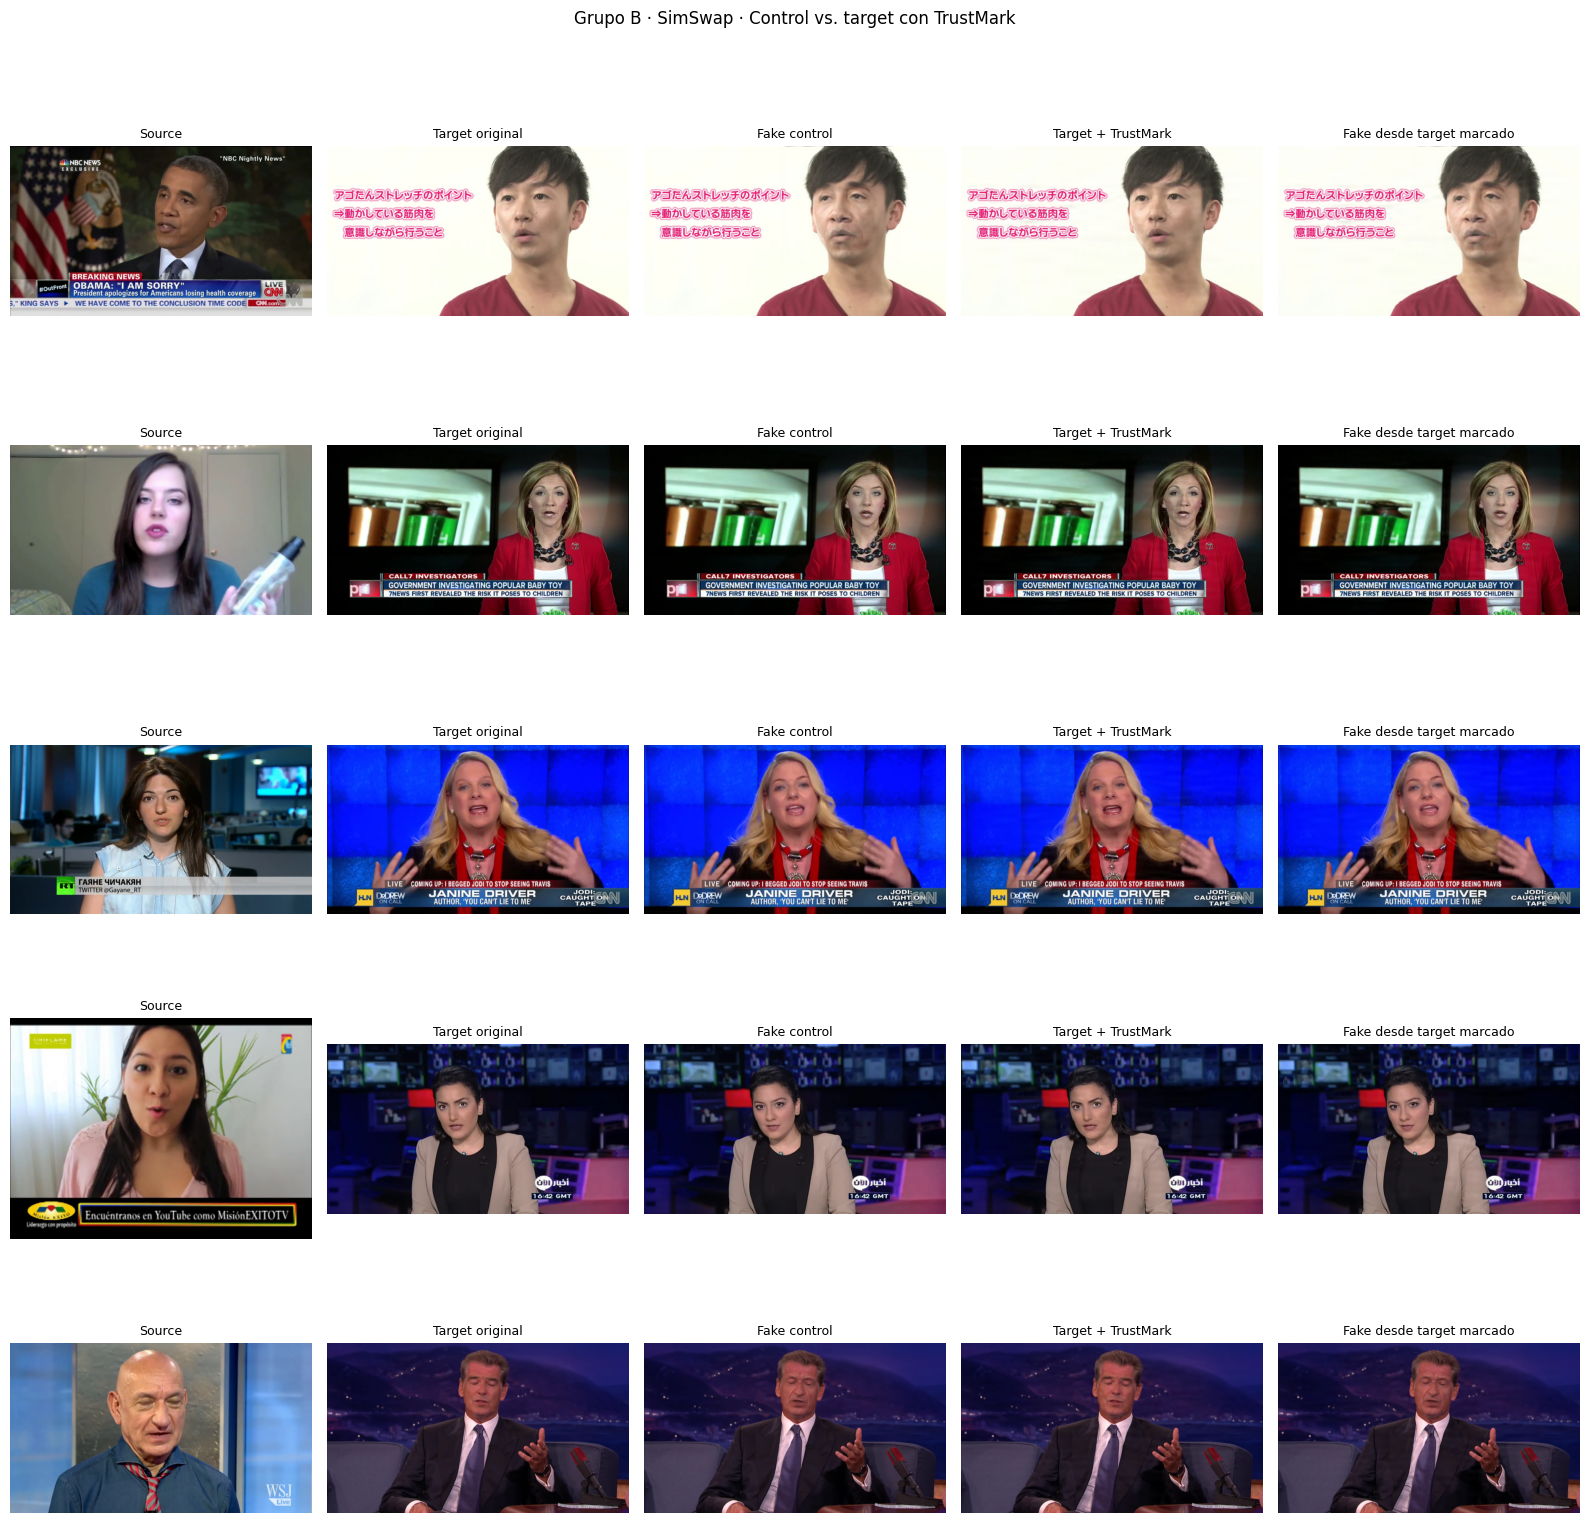

Figura: /content/drive/MyDrive/Investigacion_Deepfake_Watermarking_2026/figures/grupo_B/simswap/simswap_control_vs_watermarked.png


In [ ]:
# ============================================================
# CELDA 13 — Inspección visual
# Muestra source, target original, fake_control, target marcado
# y fake_watermarked para verificar visualmente el face swap.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

n = len(manifest_b02)
fig, axes = plt.subplots(n, 5, figsize=(16, 3.2*n))
if n == 1:
    axes = np.array([axes])

for i, row in manifest_b02.iterrows():
    paths = [
        Path(row["source_frame"]),
        Path(row["target_original"]),
        Path(row["fake_control"]),
        Path(row["target_watermarked"]),
        Path(row["fake_watermarked"]),
    ]
    titles = [
        "Source",
        "Target original",
        "Fake control",
        "Target + TrustMark",
        "Fake desde target marcado",
    ]

    for j, (path, title) in enumerate(zip(paths, titles)):
        with Image.open(path) as img:
            image = img.convert("RGB").copy()
        axes[i,j].imshow(image)
        axes[i,j].set_title(title, fontsize=9)
        axes[i,j].axis("off")

    axes[i,0].set_ylabel(str(row["pair_id"]), fontsize=10)

plt.suptitle(
    "Grupo B · SimSwap · Control vs. target con TrustMark",
    y=1.002
)
plt.tight_layout()
plt.savefig(FIG_COMPARISON, dpi=180, bbox_inches="tight")
plt.show()

print("Figura:", FIG_COMPARISON)


In [ ]:
# ============================================================
# CELDA 14 — Resumen final de B02
# Confirma las dos condiciones generadas por par y señala que
# B03 evaluará la supervivencia de TrustMark post-face-swap.
# ============================================================

print("="*60)
print("B02 COMPLETADO")
print("="*60)
print("Pares procesados:", len(manifest_b02))
print("Fake control:", len(manifest_b02))
print("Fake desde target marcado:", len(manifest_b02))
print()
print("Siguiente etapa:")
print("B03 → decode de TrustMark sobre fake_watermarked")


B02 COMPLETADO
Pares procesados: 5
Fake control: 5
Fake desde target marcado: 5

Siguiente etapa:
B03 → decode de TrustMark sobre fake_watermarked
